# Introducción

El presente proyecto analiza el comportamiento de los usuarios de una aplicación de venta de productos alimenticios. En una primera parte se estudia el embudo de ventas para identificar en qué etapas se pierden más usuarios. En una segunda parte se analizan los resultados de un test A/A/B diseñado para evaluar el impacto de un cambio tipográfico en el comportamiento de los usuarios. Los resultados de este análisis tienen como objetivo orientar las decisiones del equipo de diseño y producto

# Importación de los datos

Importamos nuestras librerías y cargamos nuestro dataset

In [ ]:
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
from matplotlib import pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
events = pd.read_csv("datasets/logs_exp_us.csv", sep="\t")

# Exploración de los datos

Utilizaremos los métodos **.info()**, **.head()** y **.tail()** para familiarizarnos con nuestros datos y buscaremos valores nulos y duplicados 

In [3]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [4]:
events.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
events.tail()

,EventName,DeviceIDHash,EventTimestamp,ExpId
244121,MainScreenAppear,4599628364049201812,1565212345,247
244122,MainScreenAppear,5849806612437486590,1565212439,246
244123,MainScreenAppear,5746969938801999050,1565212483,246
244124,MainScreenAppear,5746969938801999050,1565212498,246
244125,OffersScreenAppear,5746969938801999050,1565212517,246


In [6]:
events.duplicated().sum()

np.int64(413)

Buscamos si existen usuarios registrados en mas de un grupo

In [7]:
users_in_multiple_groups = events.groupby("DeviceIDHash")["ExpId"].nunique()

users_in_multiple_groups = users_in_multiple_groups[users_in_multiple_groups > 1]

print(len(users_in_multiple_groups))

0


El DataFrame contiene el registro de los eventos realizados por usuario. Consta de 244,126 filas y cuatro columnas.

Debemos cambiar el nombre de las columnas a formato *snake_case* y el tipo de datos de la columna `EventTimestamp` que se encuentra registrada en segundos.

No se encontraron valores nulos ni duplicados implícitos pero se registraron 413 duplicados explícitos, lo cual podría deberse a un error de registro, estos serán eliminados dado que no nos aportan información relevante para el análisis en curso.

# Procesamiento de los datos

## Encabezados

Comenzamos cambiando el formato de los encabezados a *snake_case*

In [8]:
events.columns = ["event_name", "device_id", "event_timestamp", "experiment_id"]
events.columns

Index(['event_name', 'device_id', 'event_timestamp', 'experiment_id'], dtype='object')

## Tipo de datos `event_timestamp`

Cambiamos el tipo de datos de la columna `event_timestamp` a *datetime*

In [9]:
events["event_timestamp"] = pd.to_datetime(events["event_timestamp"], unit="s")

print(events["event_timestamp"].dtype)

datetime64[ns]


## Duplicados

Eliminamos los duplicados de nuestro DataFrame

In [10]:
events = events.drop_duplicates()

print(events.duplicated().sum())

0


## Columna `date`

Agregamos una columna que incluya unicamente la fecha de los eventos

In [11]:
events["date"] = events["event_timestamp"].dt.date

events.head()

,event_name,device_id,event_timestamp,experiment_id,date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


# Estudio de los datos

## ¿Cuantos eventos hay registrados?

Según el método **.info()** que utilizamos anteriormente, existe un registro de 244,126 eventos, sin embargo, después de eliminar los 413 eventos duplicados nos quedamos con un total de 243,713 eventos registrados.

# ¿Cuántos usuarios hay en los registros?

In [12]:
unique_users = events["device_id"].nunique()

print(f"En total hay {unique_users} usuarios registrados")

En total hay 7551 usuarios registrados


Existe un total de 7551 usuarios registrados.

*NOTA: El identificador utilizado es por dispositivo, por lo que un mismo usuario podría estar representado múltiples veces si accede desde diferentes dispositivos. Para efectos de este análisis asumimos que cada `device_id` corresponde a un usuario único.*

# ¿Cuál es el promedio de eventos por usuario?

In [13]:
events_by_user = events.groupby("device_id")["event_name"].count().mean()

print(f"Los eventos promedio por usuario son: {events_by_user: .2f}")

Los eventos promedio por usuario son:  32.28


Cada usuario tiene un promedio de 32.28 eventos registrados, lo que indica un nivel de interacción considerable con la aplicación.

## ¿Qué periodo de tiempo cubren los datos?

In [14]:
print(events["event_timestamp"].min())
print(events["event_timestamp"].max())

2019-07-25 04:43:36
2019-08-07 21:15:17


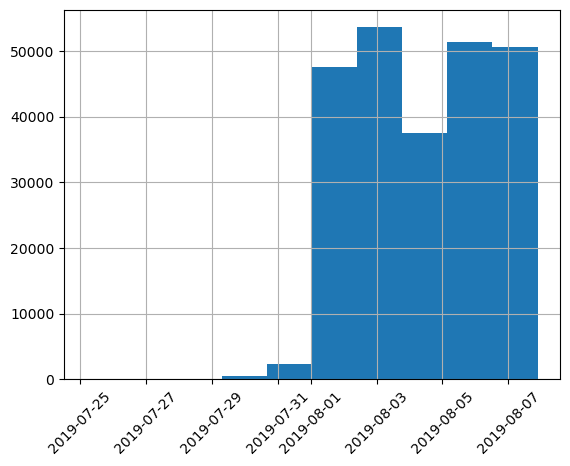

In [15]:
events["event_timestamp"].hist()

plt.xticks(rotation=45);

El histograma nos muestra que los registros anteriores al primero de agosto no son suficientes para realizar nuestro análisis, por lo que unicamente tomaremos en cuenta los eventos registrados a partir de esa fecha

In [16]:
events_filtered = events[events["event_timestamp"] >= "2019-08-01"]

print(events_filtered.shape)
print(events_filtered["device_id"].nunique())

(240887, 5)
7534


Después de filtrar los datos nos quedamos con 240,887 registros y 7534 usuarios lo que implica que se perdieron 2826 registros y 17 usuarios

Es decir que se perdió una cantidad mínima de usuarios y registros y es seguro continuar con el análisis

In [17]:
events_filtered["experiment_id"].unique()

array([246, 247, 248])

Se confirmó la presencia de los tres grupos experimentales: 246, 247 (grupos de control) y 248 (grupo de prueba).

# Análisis del embudo de ventas

## ¿Qué eventos hay en los registros y con qué frecuencia ocurren?

In [18]:
events_frequency = events_filtered["event_name"].value_counts()

print(events_frequency)

event_name
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: count, dtype: int64


Se identificaron 5 eventos únicos. Se establece la siguiente secuencia del embudo: MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful. El evento Tutorial se excluye del embudo por ser opcional y no representar un paso necesario en el proceso de conversión.

## ¿Cuántos usuarios únicos realizaron cada evento?

In [19]:
events_by_user = events_filtered.groupby("event_name")["device_id"].nunique()

events_by_user.sort_values(ascending=False)

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: device_id, dtype: int64

Se observa que 115 usuarios (7534 - 7419) no registraron el evento MainScreenAppear, lo que sugiere que accedieron a la aplicación directamente desde una pantalla diferente a la principal.

Calculamos la proporción de usuarios que realizaron cada acción al menos una vez

In [20]:
print(events_by_user / events_filtered["device_id"].nunique())

event_name
CartScreenAppear          0.50
MainScreenAppear          0.98
OffersScreenAppear        0.61
PaymentScreenSuccessful   0.47
Tutorial                  0.11
Name: device_id, dtype: float64


Ordenamos las proporciones según el orden del embudo

In [21]:
funnel_order = ["MainScreenAppear", "OffersScreenAppear", "CartScreenAppear", "PaymentScreenSuccessful"]

print(events_by_user[funnel_order] / events_filtered["device_id"].nunique())

event_name
MainScreenAppear          0.98
OffersScreenAppear        0.61
CartScreenAppear          0.50
PaymentScreenSuccessful   0.47
Name: device_id, dtype: float64


## ¿Que proporción de los usuarios pasan de una etapa a otra?

In [22]:
funnel = events_by_user[funnel_order]
conversion_steps = funnel / funnel.shift(1)
print(conversion_steps)


event_name
MainScreenAppear           NaN
OffersScreenAppear        0.62
CartScreenAppear          0.81
PaymentScreenSuccessful   0.95
Name: device_id, dtype: float64


## ¿En qué etapa pierdes más usuarios?

La etapa con mayor pérdida de usuarios es la transición de MainScreenAppear a OffersScreenAppear, donde solo el 62% de los usuarios continúa. Esto podría indicar que la pantalla principal no es suficientemente atractiva o clara para motivar al usuario a explorar las ofertas. Sin embargo, las altas tasas de conversión en las etapas siguientes (81% de ofertas a carrito y 95% de carrito a pago) sugieren que los usuarios que sí avanzan tienen alta intención de compra, lo que apunta a un problema de captación más que de producto o precio. Sería recomendable revisar el diseño y la claridad de la pantalla principal.

Adicionalmente, sería valioso analizar las fuentes de tráfico para determinar si el problema está en la calidad de los usuarios que llegan a la app.

## ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [23]:
succesful_users_ratio = events_by_user["PaymentScreenSuccessful"] / events_filtered["device_id"].nunique()

print(f"El {succesful_users_ratio:.1%} de los usuarios completo todo el proceso hasta el pago")

El 47.0% de los usuarios completo todo el proceso hasta el pago


En total, el 47% de los usuarios completa todo el proceso desde la pantalla principal hasta el pago

# Análisis de la prueba A/A/B

## ¿Cuantos usuarios hay en cada grupo?

In [24]:
users_by_experiments = events_filtered.groupby("experiment_id")["device_id"].nunique()

print(users_by_experiments)

experiment_id
246    2484
247    2513
248    2537
Name: device_id, dtype: int64


La cantidad de usuarios en cada grupo es similar por lo que es seguro continuar con la prueba

A continuacion crearemos una variable para cada grupo

In [25]:
group_246 = events_filtered[events_filtered["experiment_id"] == 246]

group_247 = events_filtered[events_filtered["experiment_id"] == 247]

group_248 = events_filtered[events_filtered["experiment_id"] == 248]

## ¿Existe una diferencia estadísticamente significativa entre los grupos de control?

*NOTA: Para este análisis se realizaron un total de 16 pruebas de hipótesis estadísticas. Con un nivel de significancia estándar de 0.05, existe una probabilidad del 5% de obtener un falso positivo en cada prueba individual. Al realizar múltiples pruebas, esta probabilidad se acumula y aumenta el riesgo de concluir erróneamente que existe una diferencia significativa.*

*Para controlar este riesgo se aplicó la corrección de Bonferroni, ajustando el nivel de significancia a 0.05/16 = 0.003. Este método es conservador, lo que significa que reduce los falsos positivos a costa de ser más estricto, aunque podría aumentar el riesgo de falsos negativos. Dado que el cambio evaluado es tipográfico y de bajo riesgo, se considera que minimizar los falsos positivos es la prioridad correcta en este contexto.*

Calculamos la tasa de conversion de cada grupo

In [26]:
# Obtenemos los usuarios por evento 
events_by_user_246 = group_246.groupby("event_name")["device_id"].nunique()
events_by_user_247 = group_247.groupby("event_name")["device_id"].nunique()
events_by_user_248 = group_248.groupby("event_name")["device_id"].nunique() # Se usara más adelante

# Calculamos la conversion de cada grupo
conversion_246 = events_by_user_246["PaymentScreenSuccessful"]/group_246["device_id"].nunique()
conversion_247 = events_by_user_247["PaymentScreenSuccessful"]/group_247["device_id"].nunique()

print(f"Conversión grupo 246: {conversion_246:.1%}")
print(f"Conversión grupo 247: {conversion_247:.1%}")

Conversión grupo 246: 48.3%
Conversión grupo 247: 46.1%


Realizamos un ztest

In [27]:
successes = [events_by_user_246["PaymentScreenSuccessful"], events_by_user_247["PaymentScreenSuccessful"]]
nobs = [group_246["device_id"].nunique(), group_247["device_id"].nunique()]

stat, p_value = proportions_ztest(successes, nobs)

print(f"P-value: {p_value:.3f}")


P-value: 0.115


Dado que el p-value es de 0.115, no existe diferencia estadísticamente significativa entre los grupos de control 246 y 247, cuyas tasas de conversión son similares (48.3% y 46.1% respectivamente). Esto confirma que la división aleatoria de usuarios fue correcta y que ambos grupos son comparables entre sí. Cualquier diferencia que observemos posteriormente entre el grupo de prueba (248) y los grupos de control no podrá atribuirse a un sesgo en la asignación. 

## Diferencia estadística por evento entre grupos de control

Comenzamos definiendo la función que nos ayudara a realizar nuestro calculo

In [28]:
def event_significance(event_name, group_1, group_1_df, group_2, group_2_df):
    # Total de usuarios que realizaron el evento
    print(f"{group_1[event_name]} usuarios del grupo 1 realizaron esta acción")
    print(f"{group_2[event_name]} usuarios del grupo 2 realizaron esta acción")
    
    # Proporcion de los usuarios que realizaron el evento
    group_1_proportion = group_1[event_name]/group_1_df["device_id"].nunique()
    group_2_proportion = group_2[event_name]/group_2_df["device_id"].nunique()
    
    print(f"La proporcion de usuarios del grupo 1 que realizaron este evento es del {group_1_proportion:.1%}")
    print(f"La proporcion de usuarios del grupo 2 que realizaron este evento es del {group_2_proportion:.1%}")
    
    # Ztest
    successes = [group_1[event_name], group_2[event_name]]
    nobs = [group_1_df["device_id"].nunique(), group_2_df["device_id"].nunique()]
    
    stat, p_value = proportions_ztest(successes, nobs)
    
    print(f"P-value: {p_value:.3f}")

Obtenemos los eventos más populares para realizar nuestros cálculos por orden de popularidad

In [29]:
print(events_by_user_246.sort_values(ascending=False))
print()
print(events_by_user_247.sort_values(ascending=False))

event_name
MainScreenAppear           2450
OffersScreenAppear         1542
CartScreenAppear           1266
PaymentScreenSuccessful    1200
Tutorial                    278
Name: device_id, dtype: int64

event_name
MainScreenAppear           2476
OffersScreenAppear         1520
CartScreenAppear           1238
PaymentScreenSuccessful    1158
Tutorial                    283
Name: device_id, dtype: int64


### MainScreenAppear

In [30]:
event_significance("MainScreenAppear", events_by_user_246, group_246, events_by_user_247, group_247)

2450 usuarios del grupo 1 realizaron esta acción
2476 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 98.6%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 98.5%
P-value: 0.757


### OffersScreenAppear

In [31]:
event_significance("OffersScreenAppear", events_by_user_246, group_246, events_by_user_247, group_247)

1542 usuarios del grupo 1 realizaron esta acción
1520 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 62.1%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 60.5%
P-value: 0.248


### CartScreenAppear

In [32]:
event_significance("CartScreenAppear", events_by_user_246, group_246, events_by_user_247, group_247)

1266 usuarios del grupo 1 realizaron esta acción
1238 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 51.0%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 49.3%
P-value: 0.229


### PaymentScreenSuccessful

In [33]:
event_significance("PaymentScreenSuccessful", events_by_user_246, group_246, events_by_user_247, group_247)

1200 usuarios del grupo 1 realizaron esta acción
1158 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 48.3%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 46.1%
P-value: 0.115


### Conclusión

En todos los eventos, los grupos 246 y 247 muestran tasas de conversión muy similares y p-values superiores a 0.003, confirmando que no existe diferencia estadísticamente significativa entre los dos grupos de control. Esto valida que la división aleatoria fue correcta y que ambos grupos son comparables, por lo que cualquier diferencia que se observe con el grupo 248 podrá atribuirse al cambio de fuentes y no a un sesgo en la asignación.

## Diferencia estadística por evento entre los grupos 246 y 248

### MainScreenAppear

In [34]:
event_significance("MainScreenAppear", events_by_user_246, group_246, events_by_user_248, group_248)

2450 usuarios del grupo 1 realizaron esta acción
2493 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 98.6%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 98.3%
P-value: 0.295


### OffersScreenAppear

In [35]:
event_significance("OffersScreenAppear", events_by_user_246, group_246, events_by_user_248, group_248)

1542 usuarios del grupo 1 realizaron esta acción
1531 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 62.1%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 60.3%
P-value: 0.208


### CartScreenAppear

In [36]:
event_significance("CartScreenAppear", events_by_user_246, group_246, events_by_user_248, group_248)

1266 usuarios del grupo 1 realizaron esta acción
1230 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 51.0%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 48.5%
P-value: 0.078


### PaymentScreenSuccessful

In [37]:
event_significance("PaymentScreenSuccessful", events_by_user_246, group_246, events_by_user_248, group_248)

1200 usuarios del grupo 1 realizaron esta acción
1181 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 48.3%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 46.6%
P-value: 0.212


## Diferencia estadística por evento entre los grupos 247 y 248

### MainScreenAppear

In [38]:
event_significance("MainScreenAppear", events_by_user_247, group_247, events_by_user_248, group_248)

2476 usuarios del grupo 1 realizaron esta acción
2493 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 98.5%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 98.3%
P-value: 0.459


### OffersScreenAppear

In [39]:
event_significance("OffersScreenAppear", events_by_user_247, group_247, events_by_user_248, group_248)

1520 usuarios del grupo 1 realizaron esta acción
1531 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 60.5%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 60.3%
P-value: 0.920


### CartScreenAppear

In [40]:
event_significance("CartScreenAppear", events_by_user_247, group_247, events_by_user_248, group_248)

1238 usuarios del grupo 1 realizaron esta acción
1230 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 49.3%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 48.5%
P-value: 0.579


### PaymentScreenSuccessful

In [41]:
event_significance("PaymentScreenSuccessful", events_by_user_247, group_247, events_by_user_248, group_248)

1158 usuarios del grupo 1 realizaron esta acción
1181 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 46.1%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 46.6%
P-value: 0.737


## Diferencia estadística por evento entre los grupos 246, 247 y 248 

Para llevar a cabo las siguientes pruebas debemos unificar nuestros grupos de control

In [42]:
events_by_user_control = events_by_user_246.add(events_by_user_247)

group_control = pd.concat([group_246, group_247])

Verificamos que los datos combinados son correctos antes de continuar.

In [43]:
print(events_by_user_control.sort_values(ascending=False))
print()
print(group_control["device_id"].nunique())

event_name
MainScreenAppear           4926
OffersScreenAppear         3062
CartScreenAppear           2504
PaymentScreenSuccessful    2358
Tutorial                    561
Name: device_id, dtype: int64

4997


### MainScreenAppear

In [44]:
event_significance("MainScreenAppear", events_by_user_control, group_control, events_by_user_248, group_248)

4926 usuarios del grupo 1 realizaron esta acción
2493 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 98.6%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 98.3%
P-value: 0.294


### OffersScreenAppear

In [45]:
event_significance("OffersScreenAppear", events_by_user_control, group_control, events_by_user_248, group_248)

3062 usuarios del grupo 1 realizaron esta acción
1531 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 61.3%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 60.3%
P-value: 0.434


### CartScreenAppear

In [46]:
event_significance("CartScreenAppear", events_by_user_control, group_control, events_by_user_248, group_248)

2504 usuarios del grupo 1 realizaron esta acción
1230 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 50.1%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 48.5%
P-value: 0.182


### PaymentScreenSuccessful

In [47]:
event_significance("PaymentScreenSuccessful", events_by_user_control, group_control, events_by_user_248, group_248)

2358 usuarios del grupo 1 realizaron esta acción
1181 usuarios del grupo 2 realizaron esta acción
La proporcion de usuarios del grupo 1 que realizaron este evento es del 47.2%
La proporcion de usuarios del grupo 2 que realizaron este evento es del 46.6%
P-value: 0.600


## Conclusión prueba A/A/B

Ninguna de las 16 pruebas realizadas arrojó un p-value inferior al nivel de significancia ajustado de 0.003 (corrección de Bonferroni), lo que indica que no existe diferencia estadísticamente significativa entre los grupos de prueba y control en ningún evento del embudo. Las tasas de conversión fueron consistentemente similares entre los tres grupos, lo que sugiere que el cambio tipográfico no tiene impacto en el comportamiento de los usuarios.

Por lo tanto, se recomienda no implementar el cambio de fuentes, ya que no genera ninguna mejora medible. El hallazgo más relevante del análisis sigue siendo la pérdida significativa de usuarios entre MainScreenAppear y OffersScreenAppear (solo el 62% avanza), lo que representa una oportunidad de mejora mayor que el cambio tipográfico probado.

# Conclusión general

El presente análisis tuvo dos objetivos principales: estudiar el embudo de ventas de la aplicación e identificar el impacto del cambio tipográfico probado en el test A/A/B.
En el embudo de ventas se identificó que el 47% de los usuarios completa todo el proceso hasta el pago. La mayor pérdida ocurre en la transición de la pantalla principal a la pantalla de ofertas, donde solo el 62% de los usuarios continúa. Las etapas posteriores muestran tasas de conversión altas (81% y 95%), lo que indica que el problema no es el producto sino la captación inicial dentro de la app.

En cuanto al test A/A/B, los 16 análisis estadísticos realizados con un nivel de significancia ajustado de 0.003 confirman que el cambio de fuentes no genera ninguna diferencia significativa en el comportamiento de los usuarios. Se recomienda no implementar el cambio y enfocar los recursos en mejorar la pantalla principal para reducir la pérdida de usuarios en la primera etapa del embudo.